[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/AASHIR/hw2-2/HW2.2/HW2_2_probability.ipynb)

# homework 2.2: probability and random variables

Aashir Javed | MAT 422 | Fall 2026

I started with a die because there are only six outcomes, so the probabilities are easy to check by hand. From there, we can see what changes when we know something about the roll. The coin flips and waiting-time examples show the difference between counting separate outcomes and finding probability over an interval.

Run the cells from top to bottom. The examples use NumPy, Matplotlib, and SciPy, which are already available in Colab. All probabilities below come from stated models, not collected data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from scipy.stats import norm

np.set_printoptions(precision=4, suppress=True)

## 2.2.1 probability axioms

The sample space $\Omega$ contains all possible outcomes. An event is a subset of that space. A probability model has three basic rules:

1. $P(A)\geq 0$ for every event $A$.
2. $P(\Omega)=1$.
3. For pairwise disjoint events, $P(\bigcup_i A_i)=\sum_i P(A_i)$.

The third rule is called countable additivity. With the die, we can check it using a few events that do not overlap. That shows how the rule works in this example, but it does not prove the general rule.

For a fair six-sided die, each outcome has probability $1/6$, so $P(A)=|A|/6$. Let $A$ be an even roll and $B$ be a roll greater than 3. These events overlap at 4 and 6. That matters because adding $P(A)$ and $P(B)$ by themselves would count those outcomes twice:

$$P(A\cup B)=P(A)+P(B)-P(A\cap B).$$

We can also check the complement rule, $P(A^c)=1-P(A)$, and $P(\varnothing)=0$.

In [2]:
outcomes = set(range(1, 7))
even = {2, 4, 6}
above_three = {4, 5, 6}
odd = outcomes - even

def probability(event):
    return len(event) / len(outcomes)

p_even = probability(even)
p_above_three = probability(above_three)
p_overlap = probability(even & above_three)
p_union = probability(even | above_three)
die_pmf = np.full(6, 1 / 6)

print("all outcome probabilities are nonnegative:", np.all(die_pmf >= 0))
print(f"P(sample space) = {probability(outcomes):.4f}")
print(f"P(empty event) = {probability(set()):.4f}")
print(f"P(even or odd) = {probability(even | odd):.4f}")
print(f"P(even) + P(odd) = {p_even + probability(odd):.4f}")
print(f"P(even and above 3) = {p_overlap:.4f}")
print(f"P(even or above 3) = {p_union:.4f}")
print(f"union rule gives = {p_even + p_above_three - p_overlap:.4f}")
print(f"P(not even) = {probability(odd):.4f}")

all outcome probabilities are nonnegative: True
P(sample space) = 1.0000
P(empty event) = 0.0000
P(even or odd) = 1.0000
P(even) + P(odd) = 1.0000
P(even and above 3) = 0.3333
P(even or above 3) = 0.6667
union rule gives = 0.6667
P(not even) = 0.5000


The even and odd events do not overlap, and together they cover the whole sample space. Their probabilities add to 1. For the overlapping events, the union is $\{2,4,5,6\}$, so its probability is $4/6$, not $1/2+1/2=1$. Subtracting the overlap fixes that double counting.

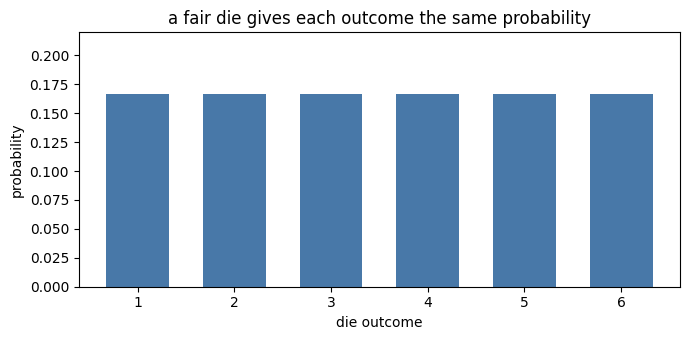

In [3]:
# Each bar is one outcome, not a whole event.
plt.figure(figsize=(7, 3.5))
plt.bar(range(1, 7), die_pmf, color="#4878a8", width=0.65)
plt.xticks(range(1, 7))
plt.ylim(0, 0.22)
plt.xlabel("die outcome")
plt.ylabel("probability")
plt.title("a fair die gives each outcome the same probability")
plt.tight_layout()
plt.show()

## 2.2.2 conditional probability

Once we know an event $B$ happened, we only consider outcomes inside $B$. For $P(B)>0$,

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}.$$

For the same die, suppose we know the roll was greater than 3. We now have just $\{4,5,6\}$ to consider, and two of those outcomes are even.

Two events are independent when $P(A\cap B)=P(A)P(B)$. If $P(B)>0$, this also means $P(A\mid B)=P(A)$. In other words, knowing that $B$ happened does not change the chance of $A$. We can check this by comparing two cases: knowing the roll is above 3 and knowing it is divisible by 3.

In [4]:
p_even_given_above_three = p_overlap / p_above_three
divisible_by_three = {3, 6}
p_even_given_divisible = probability(even & divisible_by_three) / probability(divisible_by_three)

print(f"P(even) = {p_even:.4f}")
print(f"P(even | above 3) = {p_even_given_above_three:.4f}")
print("even and above 3 are independent:",
      np.isclose(p_overlap, p_even * p_above_three))
print(f"P(even | divisible by 3) = {p_even_given_divisible:.4f}")
print("even and divisible by 3 are independent:",
      np.isclose(probability(even & divisible_by_three),
                 p_even * probability(divisible_by_three)))

P(even) = 0.5000
P(even | above 3) = 0.6667
even and above 3 are independent: False
P(even | divisible by 3) = 0.5000
even and divisible by 3 are independent: True


Knowing the roll is above 3 changes the chance of an even roll from $1/2$ to $2/3$, so those events are dependent. Knowing it is divisible by 3 leaves the chance at $1/2$, so that pair is independent.

Independent does not mean disjoint. For example, even and odd are disjoint, but knowing a roll is odd makes an even roll impossible.

### total probability and Bayes' rule

Suppose a shop gets 60% of its items from supplier $S_1$ and 40% from supplier $S_2$. In this made-up model, their defect rates are 2% and 5%, respectively. If $D$ means defective, total probability gives

$$P(D)=P(D\mid S_1)P(S_1)+P(D\mid S_2)P(S_2).$$

If an item is defective, Bayes' rule reverses the conditioning:

$$P(S_2\mid D)=\frac{P(D\mid S_2)P(S_2)}{P(D)}.$$

In [5]:
p_s1, p_s2 = 0.60, 0.40
p_defect_given_s1, p_defect_given_s2 = 0.02, 0.05

p_defect = p_defect_given_s1 * p_s1 + p_defect_given_s2 * p_s2
p_s2_given_defect = p_defect_given_s2 * p_s2 / p_defect

print(f"P(defective) = {p_defect:.4f}")
print(f"P(supplier 2 | defective) = {p_s2_given_defect:.4f}")
print(f"P(defective | supplier 2) = {p_defect_given_s2:.4f}")

P(defective) = 0.0320
P(supplier 2 | defective) = 0.6250
P(defective | supplier 2) = 0.0500


We get a 3.2% chance of an item being defective overall. Once we know an item is defective, the chance it came from supplier 2 is 62.5%. That is higher than its 40% share of all items because supplier 2 has the higher defect rate. The order matters here: $P(S_2\mid D)=0.625$ asks where a defective item came from, while $P(D\mid S_2)=0.05$ asks whether an item from supplier 2 is defective.

## 2.2.3 discrete random variables

A random variable assigns a number to each outcome. A discrete random variable takes finitely or countably many possible values. Its probability mass function (PMF) is $p(x)=P(X=x)$, with $p(x)\geq 0$ and $\sum_x p(x)=1$.

Here, $X$ counts the heads in five independent flips of a biased coin with $P(\text{heads})=0.4$. Each flip is a Bernoulli trial, and the total follows a binomial distribution:

$$P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\qquad k=0,\ldots,n.$$

The cumulative distribution function (CDF) adds the probabilities up to a value: $F(t)=P(X\leq t)$. For a discrete variable, it jumps at possible values and stays flat between them.

In [6]:
n = 5
p = 0.4
heads = np.arange(n + 1)
pmf = np.array([comb(n, k) * p**k * (1 - p)**(n - k) for k in heads])
cdf = np.cumsum(pmf)

print("heads    P(X = k)    P(X <= k)")
for k, mass, cumulative in zip(heads, pmf, cdf):
    print(f"{k:>3}      {mass:.5f}      {cumulative:.5f}")
print(f"sum of PMF = {pmf.sum():.5f}")
print(f"P(X <= 2) = {cdf[2]:.5f}")
print(f"P(X >= 3) = {1 - cdf[2]:.5f}")

heads    P(X = k)    P(X <= k)
  0      0.07776      0.07776
  1      0.25920      0.33696
  2      0.34560      0.68256
  3      0.23040      0.91296
  4      0.07680      0.98976
  5      0.01024      1.00000
sum of PMF = 1.00000
P(X <= 2) = 0.68256
P(X >= 3) = 0.31744


The PMF sums to 1, and the chance of at least three heads is 0.31744. We get that by subtracting $P(X\leq 2)$ from 1. The most likely count is two heads, but that does not mean every group of five flips will give two.

The expected value is the probability-weighted average, and variance measures spread around that average:

$$E[X]=\sum_x x p(x),\qquad \operatorname{Var}(X)=\sum_x (x-E[X])^2p(x).$$

For a binomial variable, we can also use $E[X]=np$ and $\operatorname{Var}(X)=np(1-p)$. The code below calculates both ways so we can compare the answers.

In [7]:
mean_heads = np.sum(heads * pmf)
variance_heads = np.sum((heads - mean_heads)**2 * pmf)
std_heads = np.sqrt(variance_heads)

print(f"mean from PMF = {mean_heads:.4f}; n*p = {n * p:.4f}")
print(f"variance from PMF = {variance_heads:.4f}; n*p*(1-p) = {n * p * (1-p):.4f}")
print(f"standard deviation = {std_heads:.4f}")

mean from PMF = 2.0000; n*p = 2.0000
variance from PMF = 1.2000; n*p*(1-p) = 1.2000
standard deviation = 1.0954


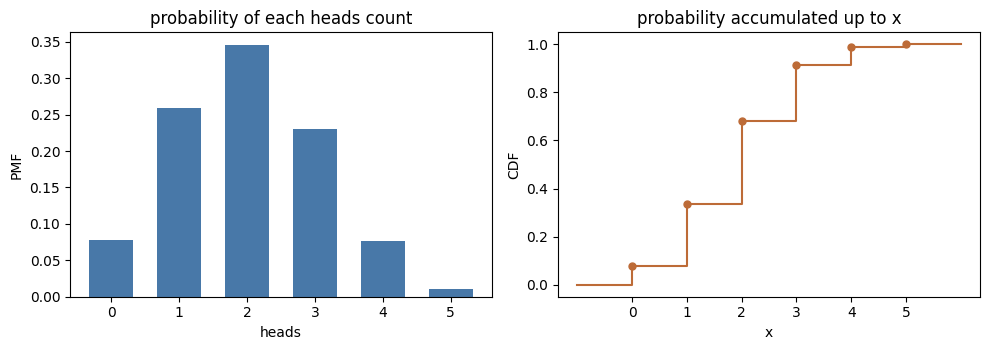

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(heads, pmf, color="#4878a8", width=0.65)
axes[0].set(title="probability of each heads count", xlabel="heads", ylabel="PMF")
axes[0].set_xticks(heads)

# The extra endpoints show the CDF is 0 before 0 and 1 after 5.
axes[1].step(np.r_[-1, heads, 6], np.r_[0, cdf, 1], where="post", color="#bd6b37")
axes[1].scatter(heads, cdf, color="#bd6b37", s=25)
axes[1].set(title="probability accumulated up to x", xlabel="x", ylabel="CDF")
axes[1].set_xticks(heads)
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

The mean is 2 heads and the variance is 1.2, giving a standard deviation of about 1.0954 heads. On the right, the filled points show the CDF includes the probability at each integer. For example, $F(2.5)=F(2)$ because a count of heads cannot land between 2 and 3.

## 2.2.4 continuous random variables

For a continuous random variable with density $f$, probabilities come from areas, not individual curve heights:

$$f(x)\geq 0,\qquad \int_{-\infty}^{\infty}f(x)\,dx=1,$$
$$F(t)=\int_{-\infty}^{t}f(x)\,dx,\qquad P(a\leq X\leq b)=F(b)-F(a).$$

At a single exact value, $P(X=x)=0$. That is why including or excluding an endpoint does not change a continuous interval probability. A density can even be greater than 1; its total area still has to be 1.

### uniform waiting time

Suppose a bus comes every 10 minutes and we arrive at a uniformly random point in that interval. Ignoring delays, the wait $T$ is uniform on $[0,10]$:

$$f_T(t)=\begin{cases}1/10&0\leq t\leq 10,\\0&\text{otherwise},\end{cases}$$
$$F_T(t)=\begin{cases}0&t<0,\\t/10&0\leq t\leq 10,\\1&t>10.\end{cases}$$

For a wait between 2 and 5 minutes, we can use $F_T(5)-F_T(2)$. We can also check it from the rectangle under the density: its width is 3 and its height is 0.1, giving a probability of 0.3.

In [9]:
wait_max = 10.0

def wait_cdf(t):
    return np.clip(np.asarray(t) / wait_max, 0, 1)

p_wait_2_to_5 = wait_cdf(5) - wait_cdf(2)
wait_mean = wait_max / 2
wait_variance = wait_max**2 / 12

print(f"total density area = {(1 / wait_max) * wait_max:.4f}")
print(f"P(2 <= T <= 5) = {p_wait_2_to_5:.4f}")
print(f"P(T = 3) = {wait_cdf(3) - wait_cdf(3):.4f}")
print(f"mean wait = {wait_mean:.4f} minutes")
print(f"variance = {wait_variance:.4f} minutes squared")
print(f"standard deviation = {np.sqrt(wait_variance):.4f} minutes")

total density area = 1.0000
P(2 <= T <= 5) = 0.3000
P(T = 3) = 0.0000
mean wait = 5.0000 minutes
variance = 8.3333 minutes squared
standard deviation = 2.8868 minutes


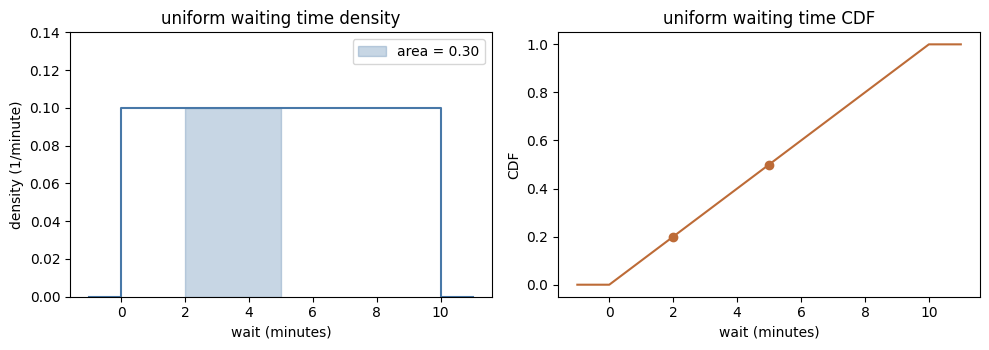

In [10]:
t = np.linspace(-1, 11, 601)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot([-1, 0, 0, 10, 10, 11], [0, 0, 0.1, 0.1, 0, 0], color="#4878a8")
axes[0].fill_between([2, 5], 0, 0.1, alpha=0.3, color="#4878a8", label="area = 0.30")
axes[0].set(title="uniform waiting time density", xlabel="wait (minutes)", ylabel="density (1/minute)")
axes[0].set_ylim(0, 0.14)
axes[0].legend()

axes[1].plot(t, wait_cdf(t), color="#bd6b37")
axes[1].scatter([2, 5], wait_cdf([2, 5]), color="#bd6b37")
axes[1].set(title="uniform waiting time CDF", xlabel="wait (minutes)", ylabel="CDF")
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

The shaded area is 0.3, which matches the difference $F_T(5)-F_T(2)=0.5-0.2$. The flat density does not mean the CDF is flat: the CDF increases steadily as we include more of the interval.

For a continuous variable, expectations and variances use integrals instead of sums:

$$E[T]=\int_{-\infty}^{\infty}t f_T(t)\,dt,\qquad
\operatorname{Var}(T)=\int_{-\infty}^{\infty}(t-E[T])^2 f_T(t)\,dt.$$

Here, $E[T]=\int_0^{10}t/10\,dt=5$ and $\operatorname{Var}(T)=\int_0^{10}(t-5)^2/10\,dt=100/12$. The average wait is 5 minutes, not a promise that a particular wait will be 5 minutes.

### a non-flat density: the normal distribution

The uniform model treats equal-length intervals inside its support equally. A normal density puts more probability near its mean. For $Z\sim N(0,1)$,

$$f_Z(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2},\qquad E[Z]=0,\quad\operatorname{Var}(Z)=1.$$

We can use the CDF to find $P(-1\leq Z\leq 1)$ by subtracting $F(-1)$ from $F(1)$. This gives the area between -1 and 1, which is different from the height of the curve at zero.

P(-1 <= Z <= 1) = 0.682689
density at zero = 0.398942
P(Z = 0) = 0.000000
mean = 0.0; variance = 1.0


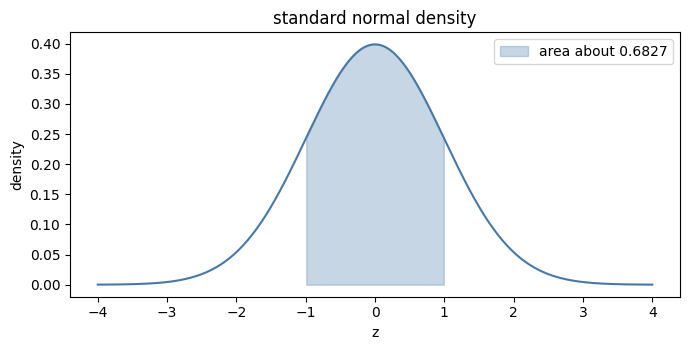

In [11]:
z = np.linspace(-4, 4, 501)
normal_pdf = norm.pdf(z)
p_within_one = norm.cdf(1) - norm.cdf(-1)

print(f"P(-1 <= Z <= 1) = {p_within_one:.6f}")
print(f"density at zero = {norm.pdf(0):.6f}")
print(f"P(Z = 0) = {norm.cdf(0) - norm.cdf(0):.6f}")
print(f"mean = {norm.mean():.1f}; variance = {norm.var():.1f}")

plt.figure(figsize=(7, 3.6))
plt.plot(z, normal_pdf, color="#4878a8")
plt.fill_between(z, normal_pdf, where=(z >= -1) & (z <= 1),
                 alpha=0.3, color="#4878a8", label="area about 0.6827")
plt.xlabel("z")
plt.ylabel("density")
plt.title("standard normal density")
plt.legend()
plt.tight_layout()
plt.show()

About 68.27% of the probability lies between -1 and 1. The density at zero is about 0.3989, but the probability of exactly zero is still 0. The plot only shows -4 to 4; the normal distribution itself extends over the entire real line.

## quick checks

The checks below compare our results with the values worked out above. Each one should print `True`. They only check these examples, so they are not a proof of the probability rules in general.

In [12]:
checks = {
    "die probabilities are nonnegative and sum to 1": np.all(die_pmf >= 0) and np.isclose(die_pmf.sum(), 1),
    "disjoint even and odd events add to 1": not (even & odd) and np.isclose(p_even + probability(odd), 1),
    "overlapping union rule works": np.isclose(p_union, p_even + p_above_three - p_overlap),
    "conditional probability is 2/3": np.isclose(p_even_given_above_three, 2 / 3),
    "Bayes calculation is 0.625": np.isclose(p_s2_given_defect, 0.625),
    "binomial PMF is valid": np.all(pmf >= 0) and np.isclose(pmf.sum(), 1),
    "binomial CDF increases to 1": np.all(np.diff(cdf) >= 0) and np.isclose(cdf[-1], 1),
    "binomial moments match the formulas": np.allclose([mean_heads, variance_heads], [n * p, n * p * (1 - p)]),
    "uniform interval and CDF endpoints match": np.allclose([p_wait_2_to_5, wait_cdf(-1), wait_cdf(11)], [0.3, 0, 1]),
    "normal interval probability matches": np.isclose(p_within_one, 0.682689492137),
}

for label, passed in checks.items():
    print(f"{label}: {bool(passed)}")

assert all(checks.values()), "one of the checks needs another look"

die probabilities are nonnegative and sum to 1: True
disjoint even and odd events add to 1: True
overlapping union rule works: True
conditional probability is 2/3: True
Bayes calculation is 0.625: True
binomial PMF is valid: True
binomial CDF increases to 1: True
binomial moments match the formulas: True
uniform interval and CDF endpoints match: True
normal interval probability matches: True


## what I took from this

The die example made conditional probability easier for me to follow. Once we know the roll is above 3, we are working with three possible outcomes instead of six. That is why the chance of an even roll changes from $1/2$ to $2/3$.

With the coin flips, we can assign a probability to an exact count, such as two heads. With the waiting time, we need an interval to get a nonzero probability. The CDF still means $P(X\leq x)$ in both cases, but we add individual probabilities for the heads count and accumulate area for the waiting time. That difference is easier to see in the plots.

## references and AI use

- MAT 422, section 2.2: probability axioms, conditional probability, and random variables.
- [Section 2.2 homework guidance](https://github.com/DynamicLLM/MAT422/blob/main/Skills/Student-Home-Work-Skills-Pack/mat422-section-2-2-probability-random-variables/references/section-2-2-guidance.md).
- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.